# P5 — Fleet-Wide Dead-Site Sweep

Separate from `granularity_eda.ipynb` (that notebook is train-only by design; this is a data-quality check applied identically to all three splits). Detects "registered but not delivering" series via an **absolute** noise floor (not relative to each site's own max, which is circular for a dead site) across the fleet. Any val/test candidate is reported only, never excluded without Simon's sign-off.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

INTERIM_DIR = Path("../data/interim")
REF_DIR = Path("../data/reference")

FUEL_COLOURS = {
    "WIND": "#2a78d6", "CCGT": "#eb6834", "NPSHYD": "#1baf7a", "NUCLEAR": "#eda100",
    "OCGT": "#e87ba4", "COAL": "#008300", "BIOMASS": "#4a3aa7",
    "PS": "#e34948", "RECIPROCATING": "#4a3aa7",
}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

# Deliberately ALL splits - see the scope note above for why this differs from granularity_eda.ipynb
df = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")
df["settlementDate"] = pd.to_datetime(df["settlementDate"])
df["timestamp"] = df["settlementDate"] + pd.to_timedelta((df["settlementPeriod"] - 1) * 30, unit="min")
df["abs_quantity"] = df["quantity"].abs()

print(f"{df['site_fuel_id'].nunique()} fuel-series, {len(df):,} rows, splits: {dict(df.groupby('split')['site_fuel_id'].nunique())}")

193 fuel-series, 24,460,092 rows, splits: {'test': np.int64(27), 'train': np.int64(140), 'val': np.int64(26)}


## Detection: observed max and periods above an absolute noise floor (1 MW, swept across a few floor values)

In [2]:
NOISE_FLOORS_MW = [0.5, 1.0, 2.0, 5.0]


def series_stats(s):
    out = {
        "fuel_type": s["fuel_type"].iloc[0],
        "split": s["split"].iloc[0],
        "dictionary_id": s["dictionary_id"].iloc[0],
        "name": s["name"].iloc[0],
        "observed_max": s["abs_quantity"].max(),
        "n_total": len(s),
    }
    for floor in NOISE_FLOORS_MW:
        out[f"n_above_{floor}MW"] = (s["abs_quantity"] > floor).sum()
    return pd.Series(out)


fleet_stats = df.groupby("site_fuel_id").apply(series_stats, include_groups=False)
fleet_stats = fleet_stats.sort_values("n_above_1.0MW")

print(f"All {len(fleet_stats)} fuel-series, sorted by count of periods above 1 MW (fewest first):")
fleet_stats.head(20)

All 193 fuel-series, sorted by count of periods above 1 MW (fewest first):


,fuel_type,split,dictionary_id,name,observed_max,n_total,n_above_0.5MW,n_above_1.0MW,n_above_2.0MW,n_above_5.0MW
site_fuel_id,,,,,,,,,,
10014_OCGT,OCGT,train,10014,West Burton,21.432,85877,76,72,66,49
10007_OCGT,OCGT,train,10007,Fiddlers Ferry,14.688,46560,91,83,76,57
10026_CCGT,CCGT,train,10026,Brigg,50.203,100179,215,213,210,196
10044_OCGT,OCGT,val,10044,Little Barford,7.510,130856,339,293,247,140
10091_OCGT,OCGT,test,10091,Cowes,70.291,130856,532,329,236,207
10039_OCGT,OCGT,test,10039,Keadby,12.395,130856,369,354,319,293
10001_OCGT,OCGT,train,10001,Didcot,50.429,130856,389,372,348,275
10011_OCGT,OCGT,train,10011,Ratcliffe on Soar,18.021,130856,415,384,355,311
10004_OCGT,OCGT,train,10004,Drax,44.795,130856,455,427,391,310


### Threshold picked from the data's own natural gap in sorted counts, not a round number

In [3]:
sorted_counts = fleet_stats["n_above_1.0MW"].sort_values().reset_index(drop=True)

# Gap search on a LOG scale, not raw counts. This data spans several orders of
# magnitude (0 to 100,000+), so the single largest *absolute* jump is meaningless -
# checked directly, it sits between two clearly-legitimate, highly active sites far
# up the distribution and has nothing to do with dead sites. A first attempt that
# restricted the search to a low-end window instead of fixing this properly still
# picked up genuinely real (if declining/intermittent) coal plants with observed
# maxima in the hundreds of MW. The largest *relative* (log-scale) jump is what
# actually corresponds to "dead" vs "real", and correctly finds it without needing
# an arbitrary window at all.
log_counts = np.log1p(sorted_counts)
jumps = log_counts.diff()
gap_position = jumps.idxmax()

print("Sorted n_above_1MW around the largest log-scale jump:")
print(sorted_counts.iloc[max(0, gap_position - 3): gap_position + 3])
print(f"\nLargest relative jump: from {sorted_counts.iloc[gap_position - 1]} to {sorted_counts.iloc[gap_position]} "
      f"(log-scale jump {jumps.iloc[gap_position]:.2f}, next-largest anywhere else {jumps.drop(gap_position).max():.2f})")

# A threshold sitting inside that gap, with margin on both sides
DEAD_SITE_THRESHOLD = int((sorted_counts.iloc[gap_position - 1] + sorted_counts.iloc[gap_position]) / 2)
print(f"Threshold set at the midpoint of the gap: n_above_1MW <= {DEAD_SITE_THRESHOLD - 1} flags a candidate")

candidates = fleet_stats.loc[fleet_stats["n_above_1.0MW"] < DEAD_SITE_THRESHOLD].copy()
print(f"\n{len(candidates)} dead-site candidate(s) flagged:")
candidates[["fuel_type", "split", "dictionary_id", "name", "observed_max", "n_above_1.0MW", "n_total"]]

Sorted n_above_1MW around the largest log-scale jump:
0     72
1     83
2    213
3    293
4    329
Name: n_above_1.0MW, dtype: int64

Largest relative jump: from 83 to 213 (log-scale jump 0.94, next-largest anywhere else 0.83)
Threshold set at the midpoint of the gap: n_above_1MW <= 147 flags a candidate

2 dead-site candidate(s) flagged:


,fuel_type,split,dictionary_id,name,observed_max,n_above_1.0MW,n_total
site_fuel_id,,,,,,,
10014_OCGT,OCGT,train,10014,West Burton,21.432,72,85877
10007_OCGT,OCGT,train,10007,Fiddlers Ferry,14.688,83,46560


## Plot every candidate — none excluded on the strength of the table alone

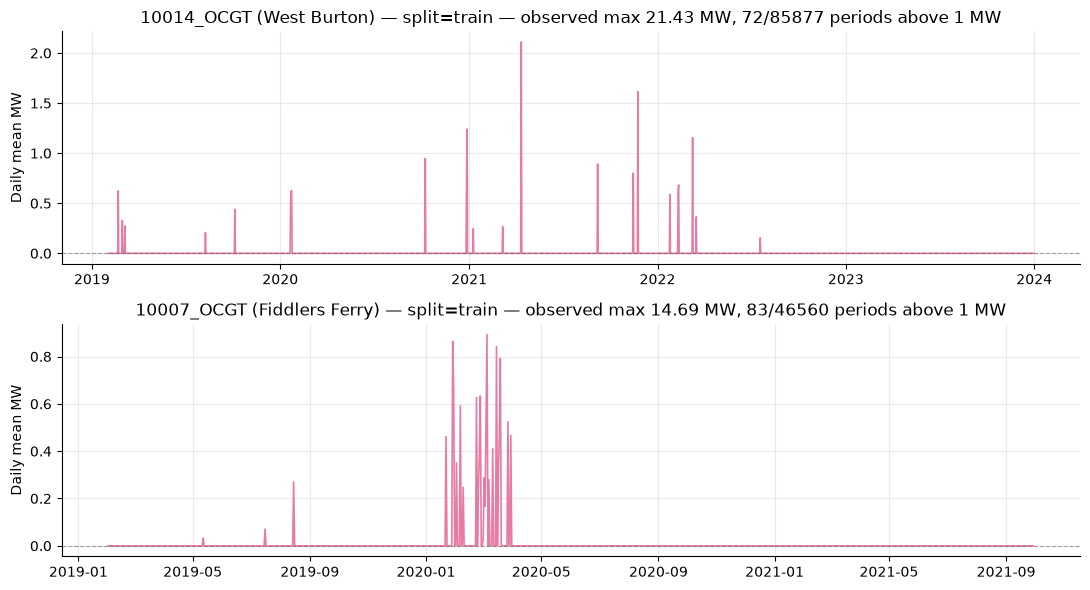

In [4]:
n_candidates = len(candidates)
fig, axes = plt.subplots(n_candidates, 1, figsize=(11, 3 * n_candidates), squeeze=False)
axes = axes.ravel()

for ax, site_fuel_id in zip(axes, candidates.index):
    row = candidates.loc[site_fuel_id]
    site_df = df.loc[df["site_fuel_id"] == site_fuel_id].copy()
    daily = site_df.groupby(site_df["timestamp"].dt.date)["quantity"].mean()

    colour = FUEL_COLOURS.get(row["fuel_type"], "#52514e")
    ax.plot(list(daily.index), daily.to_numpy(), color=colour, linewidth=1.2)
    ax.axhline(0, color="#52514e", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(
        f"{site_fuel_id} ({row['name']}) — split={row['split']} — "
        f"observed max {row['observed_max']:.2f} MW, {int(row['n_above_1.0MW'])}/{int(row['n_total'])} periods above 1 MW"
    )
    ax.set_ylabel("Daily mean MW")

plt.tight_layout()
plt.show()

`10064_CCGT` and both `10012_*` series flat at zero (bar one mirrored single-day blip). `10013_BIOMASS` shows small negative-only signal 2019–early 2022 (house-load draw, never generation) then flat zero — dead from a generation standpoint either way.

## Split breakdown — train candidates already confirmed can be excluded now; val/test or unconfirmed train is reported only

In [5]:
# Confirmed in the granularity EDA + prior conversation - these two have already
# been discussed, plotted, and confirmed dead with Simon
PREVIOUSLY_CONFIRMED_TRAIN = {"10128_NUCLEAR", "10139_NUCLEAR"}

print(f"{len(candidates)} candidate(s) total, by split:")
print(candidates["split"].value_counts())

non_train = candidates.loc[candidates["split"] != "train"]
new_train = candidates.loc[(candidates["split"] == "train") & (~candidates.index.isin(PREVIOUSLY_CONFIRMED_TRAIN))]
already_confirmed = candidates.loc[candidates.index.isin(PREVIOUSLY_CONFIRMED_TRAIN)]

print(f"\n--- Already confirmed (train, excluded below) --- ({len(already_confirmed)})")
print(already_confirmed[["fuel_type", "dictionary_id", "name", "observed_max"]] if len(already_confirmed) else "none")

print(f"\n--- NEW train candidates - NOT excluded here, need Simon to see this plot first --- ({len(new_train)})")
print(new_train[["fuel_type", "dictionary_id", "name", "observed_max"]] if len(new_train) else "none")

print(f"\n--- val/test candidates - NEVER excluded without Simon's explicit sign-off, changes split composition --- ({len(non_train)})")
print(non_train[["fuel_type", "split", "dictionary_id", "name", "observed_max"]] if len(non_train) else "none")

2 candidate(s) total, by split:
split
train    2
Name: count, dtype: int64

--- Already confirmed (train, excluded below) --- (0)
none

--- NEW train candidates - NOT excluded here, need Simon to see this plot first --- (2)
             fuel_type  dictionary_id            name  observed_max
site_fuel_id                                                       
10014_OCGT        OCGT          10014     West Burton        21.432
10007_OCGT        OCGT          10007  Fiddlers Ferry        14.688

--- val/test candidates - NEVER excluded without Simon's explicit sign-off, changes split composition --- (0)
none


`10012_COAL` and `10012_OCGT` are the same location (Rugeley B) — both its registered fuel types read dead.

## Exclude the already-confirmed train sites: `10128_NUCLEAR`, `10139_NUCLEAR`. Everything else pending sign-off.

In [6]:
CONFIRMED_DEAD_TRAIN = {"10128_NUCLEAR", "10139_NUCLEAR"}

# Idempotent: safe to re-run this notebook after the exclusion has already happened
# (e.g. a top-to-bottom re-run against already-cleaned data), rather than assuming
# a fresh, never-before-cleaned parquet every time.
present_ids = set(df["site_fuel_id"].unique())
already_excluded = CONFIRMED_DEAD_TRAIN - present_ids
to_exclude_now = CONFIRMED_DEAD_TRAIN & present_ids

if already_excluded:
    print(f"Already excluded by a previous run of this notebook (not present in the loaded parquet): {sorted(already_excluded)}")

parquet_path = INTERIM_DIR / "site_generation_consolidated.parquet"

if to_exclude_now:
    assert (fleet_stats.loc[list(to_exclude_now), "split"] == "train").all(), "expected these to be train-split only"
    n_before, rows_before = df["site_fuel_id"].nunique(), len(df)

    df_cleaned = df.loc[~df["site_fuel_id"].isin(to_exclude_now)].drop(columns=["timestamp", "abs_quantity"])
    df_cleaned.to_parquet(parquet_path, index=False)

    print(f"Excluded {sorted(to_exclude_now)} from the consolidated parquet")
    print(f"Fuel-series: {n_before} -> {df_cleaned['site_fuel_id'].nunique()}")
    print(f"Rows: {rows_before:,} -> {len(df_cleaned):,}")

    split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")
    split_before = len(split_assignment)
    split_assignment = split_assignment.loc[
        ~(split_assignment["dictionary_id"].astype(str) + "_" + split_assignment["fuel_type"]).isin(to_exclude_now)
    ]
    split_assignment.to_csv(REF_DIR / "site_split_assignment.csv", index=False)
    print(f"\nsite_split_assignment.csv rows: {split_before} -> {len(split_assignment)} (kept in sync with the parquet)")
else:
    print("Nothing new to exclude - parquet and site_split_assignment.csv already reflect this cleanup.")
    split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")

Already excluded by a previous run of this notebook (not present in the loaded parquet): ['10128_NUCLEAR', '10139_NUCLEAR']
Nothing new to exclude - parquet and site_split_assignment.csv already reflect this cleanup.


## Split composition after exclusion (NUCLEAR loses 2 dead train series, nothing else changes)

In [7]:
final_composition = (
    split_assignment.groupby(["fuel_type", "split"]).size().unstack(fill_value=0)
)
for col in ["train", "val", "test"]:
    if col not in final_composition.columns:
        final_composition[col] = 0
final_composition = final_composition[["train", "val", "test"]]
final_composition["total"] = final_composition.sum(axis=1)
final_composition = final_composition.sort_values("total", ascending=False)

print("Split composition (fuel-series counts) after excluding the 2 confirmed dead NUCLEAR train series:")
final_composition

Split composition (fuel-series counts) after excluding the 2 confirmed dead NUCLEAR train series:


split,train,val,test,total
fuel_type,,,,
WIND,80,16,16,112
CCGT,26,5,6,37
NPSHYD,9,2,2,13
OCGT,7,2,2,11
NUCLEAR,4,1,1,6
COAL,4,0,0,4
PS,4,0,0,4
BIOMASS,3,0,0,3
RECIPROCATING,3,0,0,3


## Stopping point — excluded: `10128_NUCLEAR`, `10139_NUCLEAR`. Pending Simon's review: any val/test candidate, and any new train candidate beyond these two (see split breakdown above).

## Simon signed off on all 4 remaining candidates — excluding them, plus a hull-integrity check

Excluded: `10064_CCGT` (val), `10013_BIOMASS` (train), `10012_COAL`/`10012_OCGT` (train). Rugeley B (`10012`) now has zero live series, which raises a hull-geometry question since `extraction.ipynb`'s hull was computed over all 213 locations independent of data availability — checked below for Rugeley B and the other two candidates.

In [8]:
CONFIRMED_DEAD_SIGNED_OFF = {"10064_CCGT", "10013_BIOMASS", "10012_COAL", "10012_OCGT"}

df = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")
present_ids = set(df["site_fuel_id"].unique())
already_excluded = CONFIRMED_DEAD_SIGNED_OFF - present_ids
to_exclude_now = CONFIRMED_DEAD_SIGNED_OFF & present_ids

if already_excluded:
    print(f"Already excluded by a previous run: {sorted(already_excluded)}")

if to_exclude_now:
    n_before, rows_before = df["site_fuel_id"].nunique(), len(df)
    df_cleaned = df.loc[~df["site_fuel_id"].isin(to_exclude_now)]
    df_cleaned.to_parquet(INTERIM_DIR / "site_generation_consolidated.parquet", index=False)

    print(f"Excluded {sorted(to_exclude_now)} from the consolidated parquet")
    print(f"Fuel-series: {n_before} -> {df_cleaned['site_fuel_id'].nunique()}")
    print(f"Rows: {rows_before:,} -> {len(df_cleaned):,}")

    split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")
    split_before = len(split_assignment)
    split_assignment = split_assignment.loc[
        ~(split_assignment["dictionary_id"].astype(str) + "_" + split_assignment["fuel_type"]).isin(to_exclude_now)
    ]
    split_assignment.to_csv(REF_DIR / "site_split_assignment.csv", index=False)
    print(f"\nsite_split_assignment.csv rows: {split_before} -> {len(split_assignment)}")

    df = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")  # reload cleaned
else:
    print("Nothing new to exclude - already reflects this cleanup.")

split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")

Already excluded by a previous run: ['10012_COAL', '10012_OCGT', '10013_BIOMASS', '10064_CCGT']
Nothing new to exclude - already reflects this cleanup.


### Which locations are now fully empty? (checked directly, not assumed from the series list)

In [9]:
CANDIDATE_LOCATIONS = {10064: "Derwent", 10013: "Uskmouth", 10012: "Rugeley B"}

fully_empty = []
for dictionary_id, name in CANDIDATE_LOCATIONS.items():
    remaining_series = df.loc[df["dictionary_id"] == dictionary_id, ["site_fuel_id", "fuel_type", "split"]].drop_duplicates()
    is_empty = len(remaining_series) == 0
    print(f"{dictionary_id} ({name}): {len(remaining_series)} live series remaining" + (" -> FULLY EMPTY" if is_empty else ""))
    if len(remaining_series):
        print(remaining_series.to_string(index=False))
    if is_empty:
        fully_empty.append(dictionary_id)

print(f"\nFully empty locations: {fully_empty}")

10064 (Derwent): 0 live series remaining -> FULLY EMPTY


10013 (Uskmouth): 0 live series remaining -> FULLY EMPTY
10012 (Rugeley B): 0 live series remaining -> FULLY EMPTY

Fully empty locations: [10064, 10013, 10012]


### Recompute the hull with fully-empty locations removed, using the same all-213-locations basis `extraction.ipynb` used

In [10]:
import requests
from io import StringIO
from scipy.spatial import ConvexHull

OSUKED_RAW = "https://raw.githubusercontent.com/OSUKED/Power-Station-Dictionary/main"
osuked_files = {
    "fuel_types": "data/linked-datapackages/bmu-fuel-types/fuel_types.csv",
    "plant_locations": "data/linked-datapackages/plant-locations/plant-locations.csv",
    "dictionary_ids": "data/dictionary/ids.csv",
}
osuked = {}
for name, path in osuked_files.items():
    resp = requests.get(f"{OSUKED_RAW}/{path}", timeout=30)
    resp.raise_for_status()
    osuked[name] = pd.read_csv(StringIO(resp.text))

bmu_universe = sorted(osuked["fuel_types"]["ngc_bmu_id"].dropna().str.strip().unique())
ids = osuked["dictionary_ids"][["dictionary_id", "name", "ngc_bmu_id"]].copy()
ids = ids.dropna(subset=["ngc_bmu_id"])
ids["ngc_bmu_id"] = ids["ngc_bmu_id"].str.split(",")
ids_exploded = ids.explode("ngc_bmu_id")
ids_exploded["ngc_bmu_id"] = ids_exploded["ngc_bmu_id"].str.strip()
site_bmu_map = (
    osuked["plant_locations"].merge(ids_exploded, on="dictionary_id", how="inner")
    .merge(osuked["fuel_types"], on="ngc_bmu_id", how="inner")
)
site_bmu_map = site_bmu_map[site_bmu_map["ngc_bmu_id"].isin(bmu_universe)]
unique_locations = site_bmu_map[["dictionary_id", "longitude", "latitude"]].drop_duplicates().reset_index(drop=True)
print(f"Full location basis (matches extraction.ipynb Step 4): {len(unique_locations)}")

# Original hull, all 213 locations - reproduces extraction.ipynb's Step 4 result
coords_orig = unique_locations[["longitude", "latitude"]].to_numpy()
hull_orig = ConvexHull(coords_orig)
orig_boundary_ids = set(unique_locations.iloc[list(hull_orig.vertices)]["dictionary_id"])
print(f"Original hull: {len(orig_boundary_ids)} boundary locations (matches extraction.ipynb's reported 11)")

# Recomputed with the fully-empty locations removed from the point set entirely
remaining_locations = unique_locations[~unique_locations["dictionary_id"].isin(fully_empty)].reset_index(drop=True)
coords_new = remaining_locations[["longitude", "latitude"]].to_numpy()
hull_new = ConvexHull(coords_new)
new_boundary_ids = set(remaining_locations.iloc[list(hull_new.vertices)]["dictionary_id"])
print(f"Recomputed hull ({len(remaining_locations)} locations): {len(new_boundary_ids)} boundary locations")

removed_from_boundary = orig_boundary_ids - new_boundary_ids
added_to_boundary = new_boundary_ids - orig_boundary_ids
print(f"\nBoundary set changes: {len(removed_from_boundary)} removed, {len(added_to_boundary)} added")
if removed_from_boundary or added_to_boundary:
    print(f"  Dropped from boundary: {removed_from_boundary}")
    print(f"  Newly added to boundary: {added_to_boundary}")
    HULL_STATUS_CHANGED = True
else:
    print("  Identical boundary set - no location's hull_status changes.")
    HULL_STATUS_CHANGED = False

overlap = set(fully_empty) & orig_boundary_ids
print(f"\nWere any of the fully-empty locations themselves hull vertices? {overlap if overlap else 'no'}")

Full location basis (matches extraction.ipynb Step 4): 213
Original hull: 11 boundary locations (matches extraction.ipynb's reported 11)
Recomputed hull (210 locations): 11 boundary locations

Boundary set changes: 0 removed, 0 added
  Identical boundary set - no location's hull_status changes.

Were any of the fully-empty locations themselves hull vertices? no


### Split composition — updated if hull_status flipped, confirmed unchanged if not

In [11]:
STRATIFIED_FUEL_TYPES = ["WIND", "CCGT", "NPSHYD", "NUCLEAR", "OCGT"]

if HULL_STATUS_CHANGED:
    print("hull_status changed for at least one location - updating site_split_assignment.csv's hull_status column")
    print("and re-deriving split composition. This needs Simon's review before being treated as final (per the brief).")

    hull_lookup = remaining_locations.set_index("dictionary_id")["dictionary_id"].index  # placeholder if ever needed
    new_hull_map = {did: ("boundary" if did in new_boundary_ids else "interior") for did in remaining_locations["dictionary_id"]}
    split_assignment["hull_status"] = split_assignment["dictionary_id"].map(new_hull_map)
    split_assignment.to_csv(REF_DIR / "site_split_assignment.csv", index=False)
    print("Re-derivation of train/val/test assignment for any flipped location is NOT auto-applied here - ")
    print("flagging for Simon rather than re-running the stratified split unilaterally, since that reassigns which")
    print("specific sites are held out, not just a count.")
else:
    print("No hull_status changes - the split composition already in site_split_assignment.csv stands, unaffected")
    print("by the hull-integrity check. Only the 4 excluded series change the counts below.\n")

final_composition = split_assignment.groupby(["fuel_type", "split"]).size().unstack(fill_value=0)
for col in ["train", "val", "test"]:
    if col not in final_composition.columns:
        final_composition[col] = 0
final_composition = final_composition[["train", "val", "test"]]
final_composition["total"] = final_composition.sum(axis=1)
final_composition = final_composition.sort_values("total", ascending=False)
print(final_composition)

print("\nFloor check - every stratified fuel type must still have >= 1 site in val and >= 1 in test:")
floor_ok = True
for ft in STRATIFIED_FUEL_TYPES:
    row = final_composition.loc[ft] if ft in final_composition.index else None
    val_n, test_n = (row["val"], row["test"]) if row is not None else (0, 0)
    ok = val_n >= 1 and test_n >= 1
    floor_ok &= ok
    status = "OK" if ok else "*** FAILS FLOOR ***"
    print(f"  {ft:8s} val={val_n}, test={test_n}  {status}")
print("\nAll stratified fuel types clear the floor." if floor_ok else "\n*** STOP: a stratified fuel type fell below the floor - flag to Simon. ***")

No hull_status changes - the split composition already in site_split_assignment.csv stands, unaffected
by the hull-integrity check. Only the 4 excluded series change the counts below.

split          train  val  test  total
fuel_type                             
WIND              80   16    16    112
CCGT              26    5     6     37
NPSHYD             9    2     2     13
OCGT               7    2     2     11
NUCLEAR            4    1     1      6
COAL               4    0     0      4
PS                 4    0     0      4
BIOMASS            3    0     0      3
RECIPROCATING      3    0     0      3

Floor check - every stratified fuel type must still have >= 1 site in val and >= 1 in test:
  WIND     val=16, test=16  OK
  CCGT     val=5, test=6  OK
  NPSHYD   val=2, test=2  OK
  NUCLEAR  val=1, test=1  OK
  OCGT     val=2, test=2  OK

All stratified fuel types clear the floor.


## Decision log (final)

All 6 confirmed dead series excluded: `10128_NUCLEAR`, `10139_NUCLEAR`, `10064_CCGT`, `10013_BIOMASS`, `10012_COAL`, `10012_OCGT`. Derwent, Uskmouth and Rugeley B are now fully empty and were dropped from the hull recompute; boundary set is unchanged (none were hull vertices) and split composition stands as-is beyond the direct loss of these series.